<b style="color:red;"> Plots for RQ02 </b>

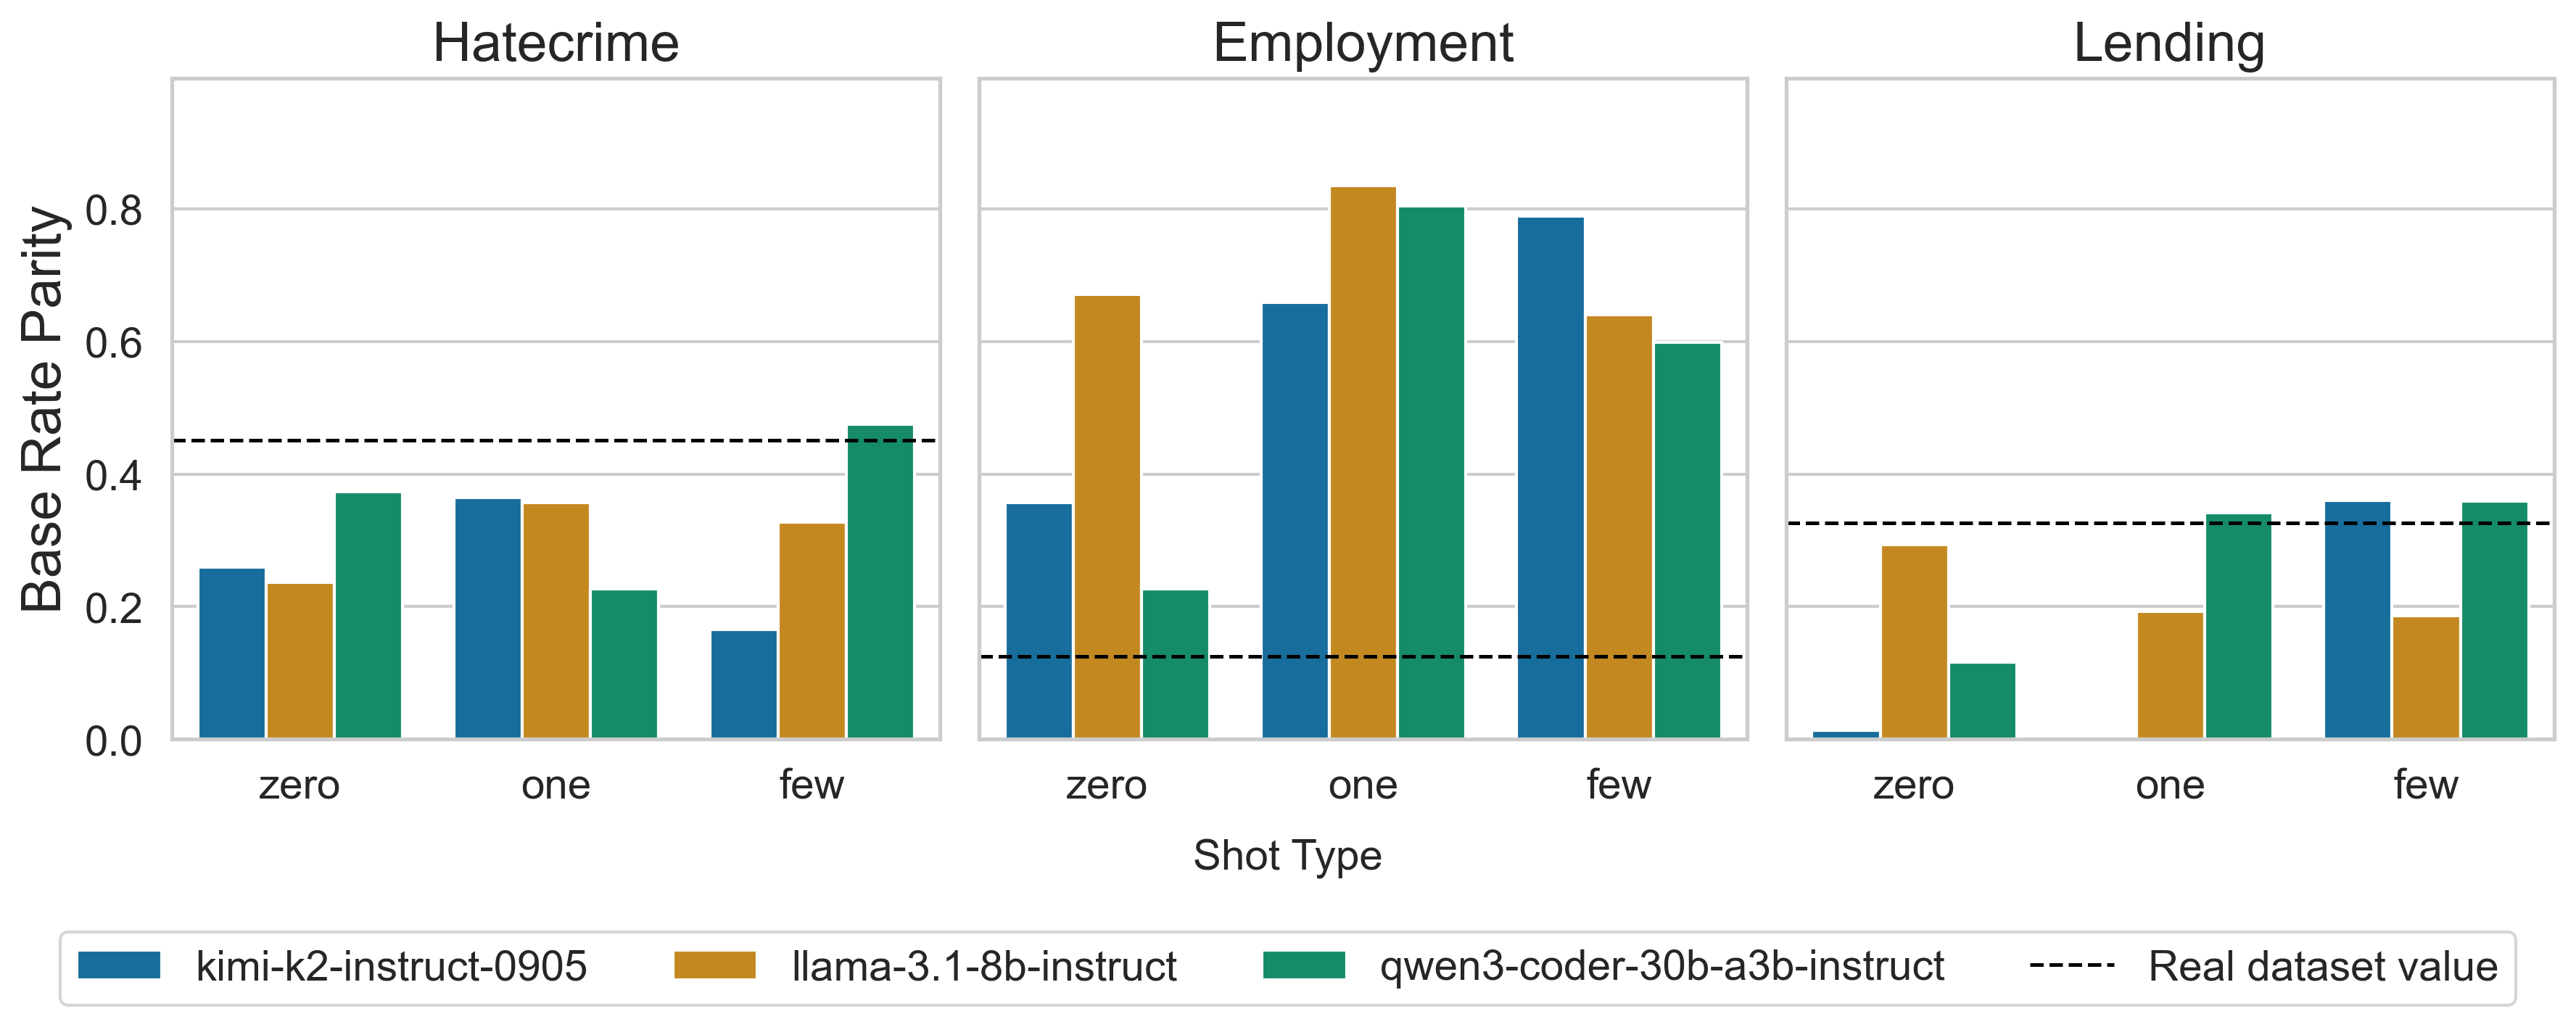

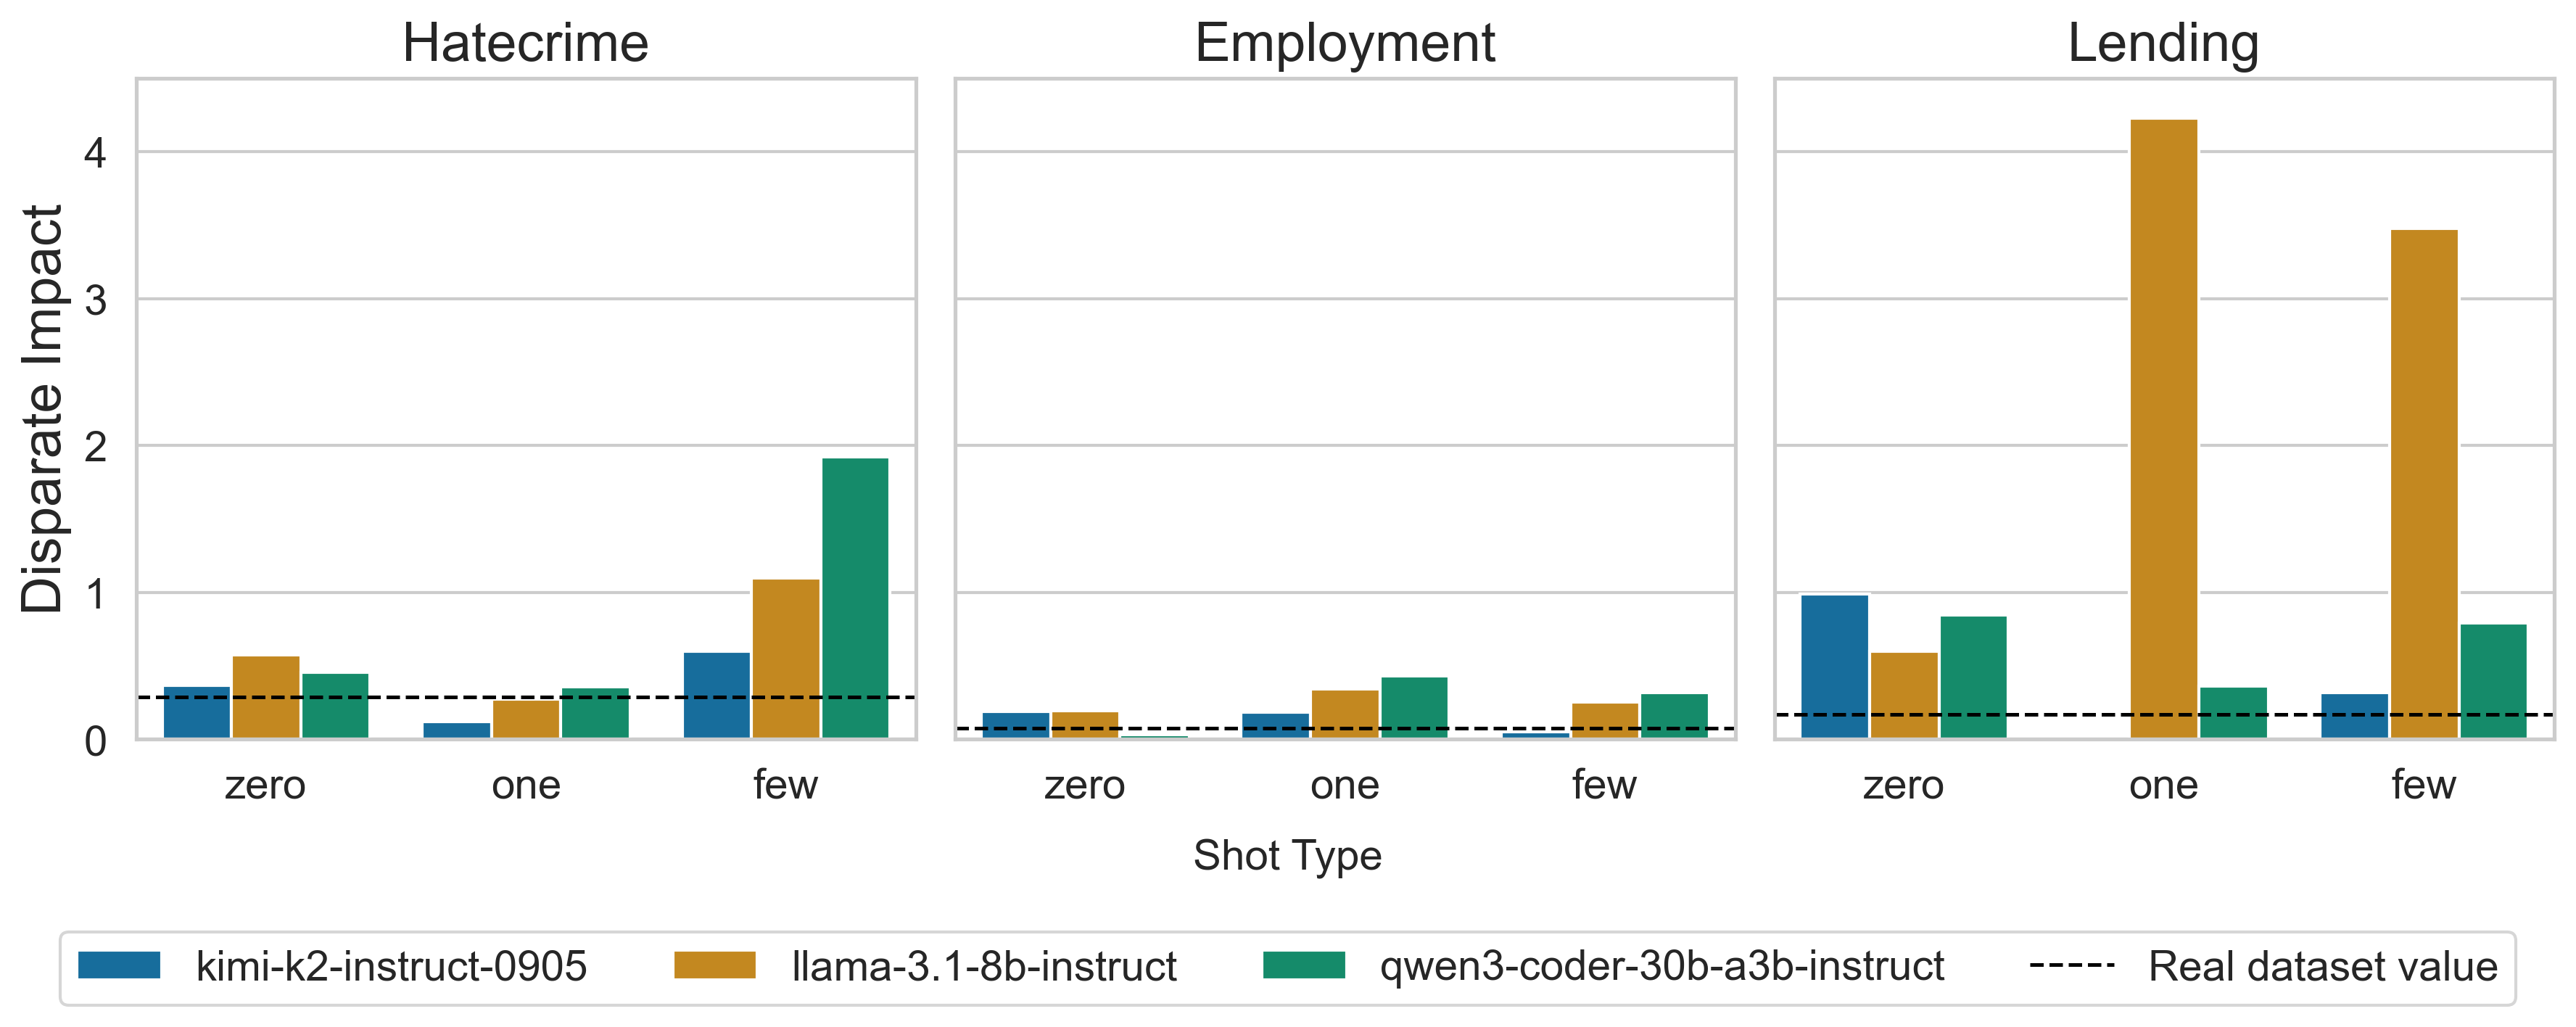

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
from functions import find_project_root


project_root = find_project_root()
experiments_dir = project_root / "notebooks" / "experiments"
if str(experiments_dir.resolve()) not in sys.path:
    sys.path.insert(0, str(experiments_dir.resolve()))

from color_palette import MODEL_ORDER, SHOT_ORDER, model_color_map

sns.set(style="whitegrid")

plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (12, 4),  
    "figure.dpi": 300,
})


def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of {candidates} found in columns {list(df.columns)}")


def _plot_metric(ax, df, value_col, title, real_value, ylabel):
    df = df.copy()

    df["shot"] = pd.Categorical(df["shot"], categories=SHOT_ORDER, ordered=True)
    df["model"] = pd.Categorical(df["model"], categories=MODEL_ORDER, ordered=True)

    palette = model_color_map(MODEL_ORDER)

    sns.barplot(
        ax=ax,
        data=df,
        x="shot",
        y=value_col,
        hue="model",
        palette=palette,
        errorbar=None,
    )

    ax.set_title(title, fontsize=18)
    ax.set_xlabel("", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=18)

    ax.tick_params(labelsize=14)

    ax.axhline(real_value, color="black", linestyle="--", linewidth=1.2, label="Real dataset value")
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    data_max = df[value_col].max()
    y_max = max(ax.get_ylim()[1], data_max * 1.1, real_value * 1.1)
    return y_max


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "analysis" / "bias_rq_02"
FIGURES_DIR = PROJECT_ROOT / "figures"



emp_bp_df = pd.read_csv(RESULTS_DIR / "employment_e01_base_rate_parity.csv")
emp_di_df = pd.read_csv(RESULTS_DIR / "employment_e02_disparate_impact.csv")
emp_md_df = pd.read_csv(RESULTS_DIR / "employment_e03_mean_difference.csv")
emp_real   = pd.read_csv(RESULTS_DIR / "employment_real_metrics.csv")

emp_bp_col = pick_col(emp_bp_df, ["bp_avg"])
emp_di_col = pick_col(emp_di_df, ["di_avg"])
emp_md_col = pick_col(emp_md_df, ["md_avg"])

emp_bp_real = emp_real[pick_col(emp_real, ["bp_avg"])].iloc[0]
emp_di_real = emp_real[pick_col(emp_real, ["di_avg"])].iloc[0]
emp_md_real = emp_real[pick_col(emp_real, ["md_avg"])].iloc[0]


lend_bp_df = pd.read_csv(RESULTS_DIR / "lending_e01_base_rate_parity.csv")
lend_di_df = pd.read_csv(RESULTS_DIR / "lending_e02_disparate_impact.csv")
lend_br_df = pd.read_csv(RESULTS_DIR / "lending_e03_base_rate.csv")
lend_real  = pd.read_csv(RESULTS_DIR / "lending_real_metrics.csv")

lend_bp_col = pick_col(lend_bp_df, ["bp_overall"])
lend_di_col = pick_col(lend_di_df, ["di_overall"])
lend_br_col = pick_col(lend_br_df, ["br_overall"])

lend_bp_real = lend_real[pick_col(lend_real, ["overall_brp"])].iloc[0]
lend_di_real = lend_real[pick_col(lend_real, ["overall_di"])].iloc[0]
lend_br_real = lend_real[pick_col(lend_real, ["overall_br"])].iloc[0]


hc_bp_df = pd.read_csv(RESULTS_DIR / "hatecrime_e01_base_rate_parity.csv")
hc_di_df = pd.read_csv(RESULTS_DIR / "hatecrime_e02_disparate_impact.csv")
hc_br_df = pd.read_csv(RESULTS_DIR / "hatecrime_e03_base_rate.csv")
hc_real  = pd.read_csv(RESULTS_DIR / "hatecrime_real_metrics.csv")

hc_bp_col = pick_col(hc_bp_df, ["brp_overall"])
hc_di_col = pick_col(hc_di_df, ["di_overall"])
hc_br_col = pick_col(hc_br_df, ["br_overall"])

hc_bp_real = hc_real[pick_col(hc_real, ["overall_brp"])].iloc[0]
hc_di_real = hc_real[pick_col(hc_real, ["overall_di"])].iloc[0]
hc_br_real = hc_real[pick_col(hc_real, ["overall_br"])].iloc[0]


fig, axes = plt.subplots(1, 3, sharey=True)

y_maxes = []
y_maxes.append(_plot_metric(
    ax=axes[0],
    df=hc_bp_df,
    value_col=hc_bp_col,
    title="Hatecrime",
    real_value=hc_bp_real,
    ylabel="Base Rate Parity",
))
y_maxes.append(_plot_metric(
    ax=axes[1],
    df=emp_bp_df,
    value_col=emp_bp_col,
    title="Employment",
    real_value=emp_bp_real,
    ylabel="",
))
y_maxes.append(_plot_metric(
    ax=axes[2],
    df=lend_bp_df,
    value_col=lend_bp_col,
    title="Lending",
    real_value=lend_bp_real,
    ylabel="",
))

y_max = max(y_maxes)
for ax in axes:
    ax.set_ylim(0, y_max)

handles, labels = axes[0].get_legend_handles_labels()
fig.text(0.5, -0.02, "Shot Type", ha="center", fontsize=14)
fig.legend(
    handles,
    labels,
    title="",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=4,
    frameon=True,
    fancybox=True,
    fontsize=14,
    title_fontsize=14,
)

fig.tight_layout(rect=(0, 0.007, 1, 1))
plt.savefig(FIGURES_DIR / "brp_all_domains.png", dpi=300, bbox_inches="tight")
plt.show()


emp_di_df_transformed = emp_di_df.copy()
emp_di_df_transformed[emp_di_col] = (emp_di_df[emp_di_col] - 1.0).abs()
emp_di_real_transformed = abs(emp_di_real - 1.0)

lend_di_df_transformed = lend_di_df.copy()
lend_di_df_transformed[lend_di_col] = (lend_di_df[lend_di_col] - 1.0).abs()
lend_di_real_transformed = abs(lend_di_real - 1.0)

hc_di_df_transformed = hc_di_df.copy()
hc_di_df_transformed[hc_di_col] = (hc_di_df[hc_di_col] - 1.0).abs()
hc_di_real_transformed = abs(hc_di_real - 1.0)

fig, axes = plt.subplots(1, 3, sharey=True)

y_maxes = []
y_maxes.append(_plot_metric(
    ax=axes[0],
    df=hc_di_df_transformed,
    value_col=hc_di_col,
    title="Hatecrime",
    real_value=hc_di_real_transformed,
    ylabel="Disparate Impact",
))
y_maxes.append(_plot_metric(
    ax=axes[1],
    df=emp_di_df_transformed,
    value_col=emp_di_col,
    title="Employment",
    real_value=emp_di_real_transformed,
    ylabel="",
))
y_maxes.append(_plot_metric(
    ax=axes[2],
    df=lend_di_df_transformed,
    value_col=lend_di_col,
    title="Lending",
    real_value=lend_di_real_transformed,
    ylabel="",
))

for ax in axes:
    ax.set_ylim(0, 4.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.text(0.5, -0.02, "Shot Type", ha="center", fontsize=14)
fig.legend(
    handles,
    labels,
    title="",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=4,
    frameon=True,
    fancybox=True,
    fontsize=14,
    title_fontsize=14,
)

fig.tight_layout(rect=(0, 0.007, 1, 1))
plt.savefig(FIGURES_DIR / "di_all_domains.png", dpi=300, bbox_inches="tight")
plt.show()


def best_per_graph(df, value_col, real_value, domain, metric_name):
    agg = df.groupby(["model", "shot"], as_index=False)[value_col].mean()
    agg["abs_diff"] = (agg[value_col] - real_value).abs()
    best_row = agg.loc[agg["abs_diff"].idxmin()]
    return {
        "Domain": domain,
        "Metric": metric_name,
        "Model": best_row["model"],
        "Shot": best_row["shot"],
        "Value": best_row[value_col],
        "Real": real_value,
        "AbsDiff": best_row["abs_diff"],
    }

best_rows = []



best_rows.append(best_per_graph(hc_bp_df, hc_bp_col, hc_bp_real,
                                "hatecrime", "BRP"))
best_rows.append(best_per_graph(hc_di_df, hc_di_col, hc_di_real,
                                "hatecrime", "DI"))

best_rows.append(best_per_graph(emp_bp_df, emp_bp_col, emp_bp_real,
                                "employment", "BRP"))
best_rows.append(best_per_graph(emp_di_df, emp_di_col, emp_di_real,
                                "employment", "DI"))


best_rows.append(best_per_graph(lend_bp_df, lend_bp_col, lend_bp_real,
                                "lending", "BRP"))
best_rows.append(best_per_graph(lend_di_df, lend_di_col, lend_di_real,
                                "lending", "DI"))



best_df = pd.DataFrame(best_rows)


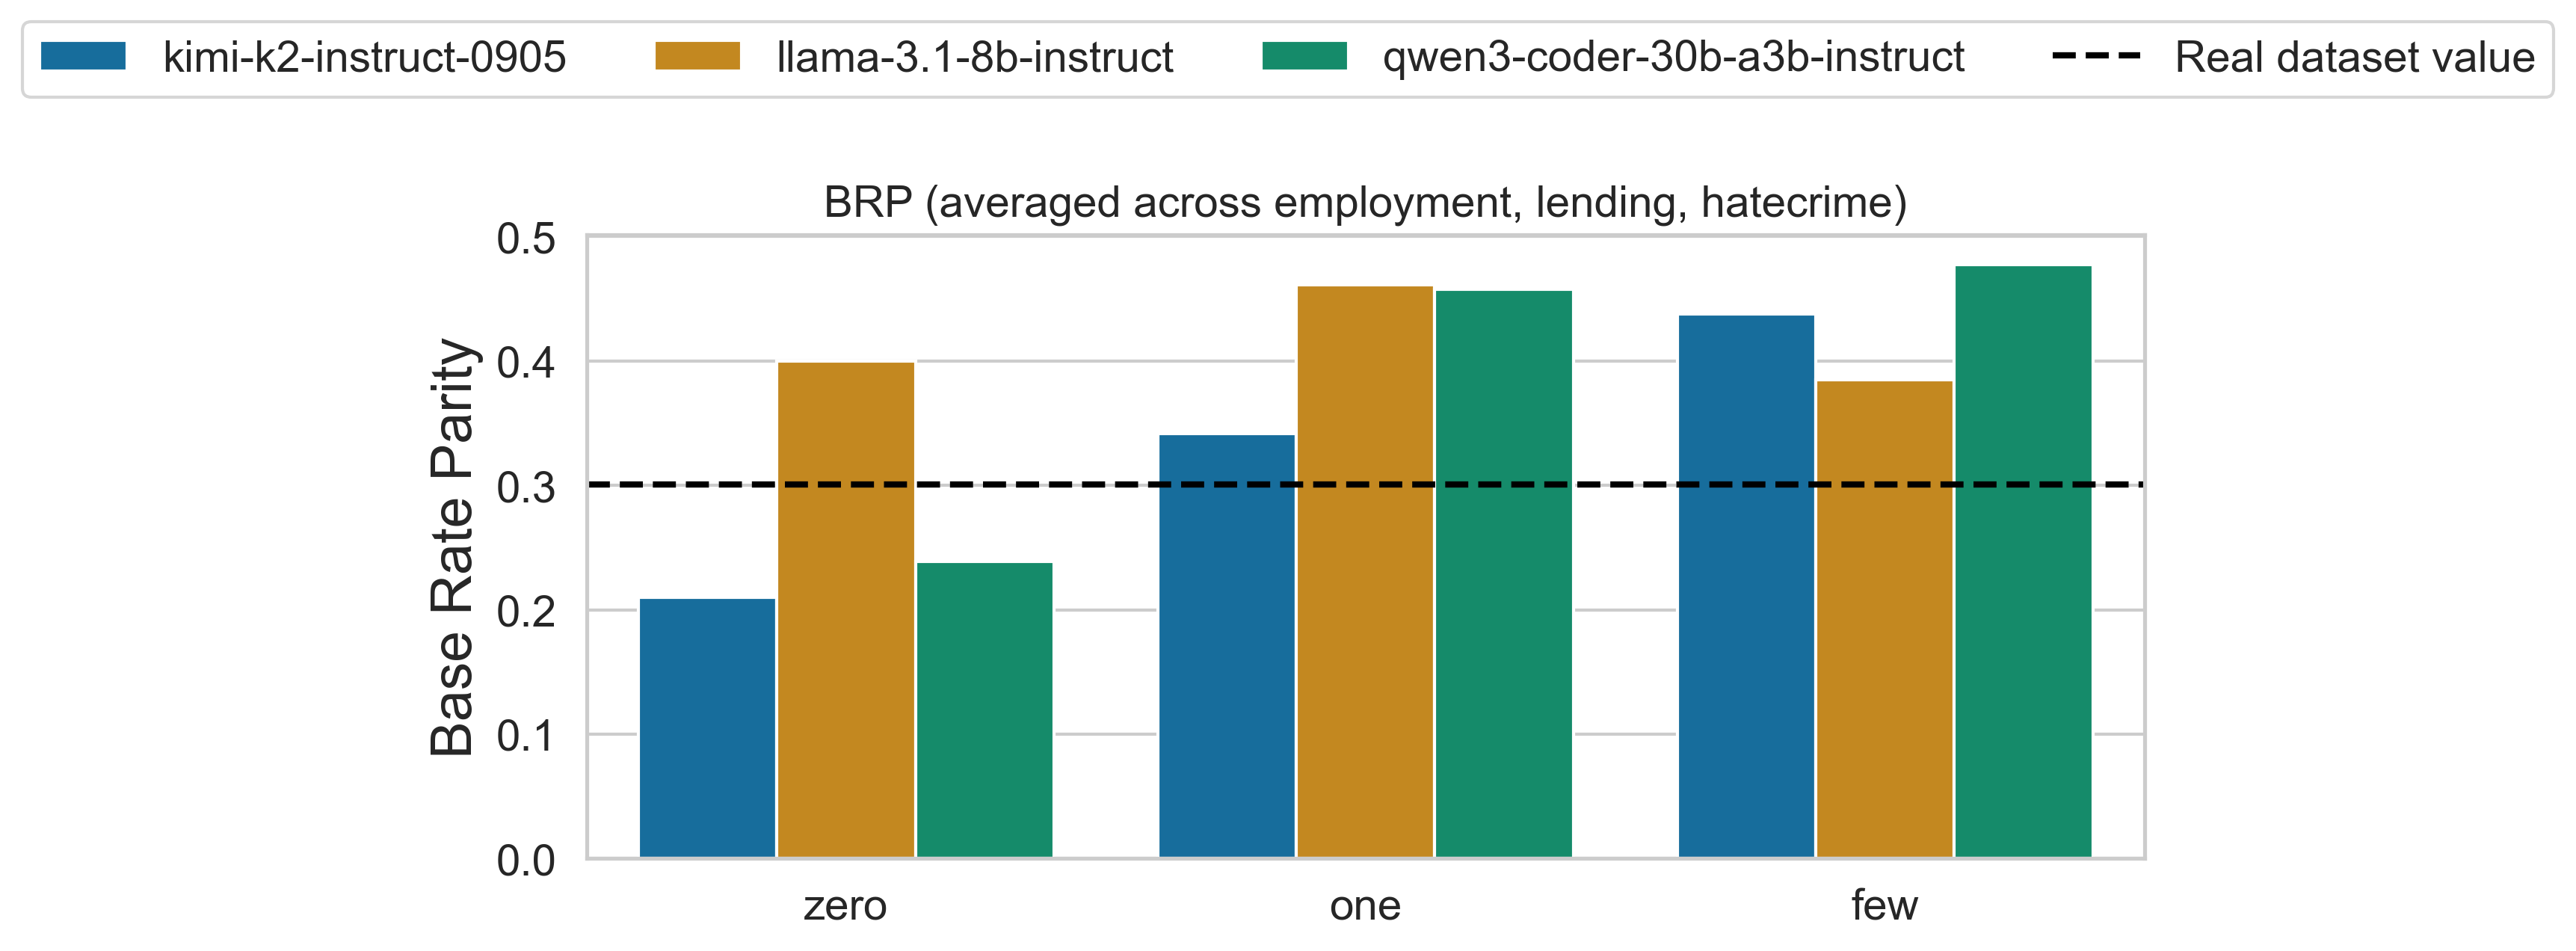

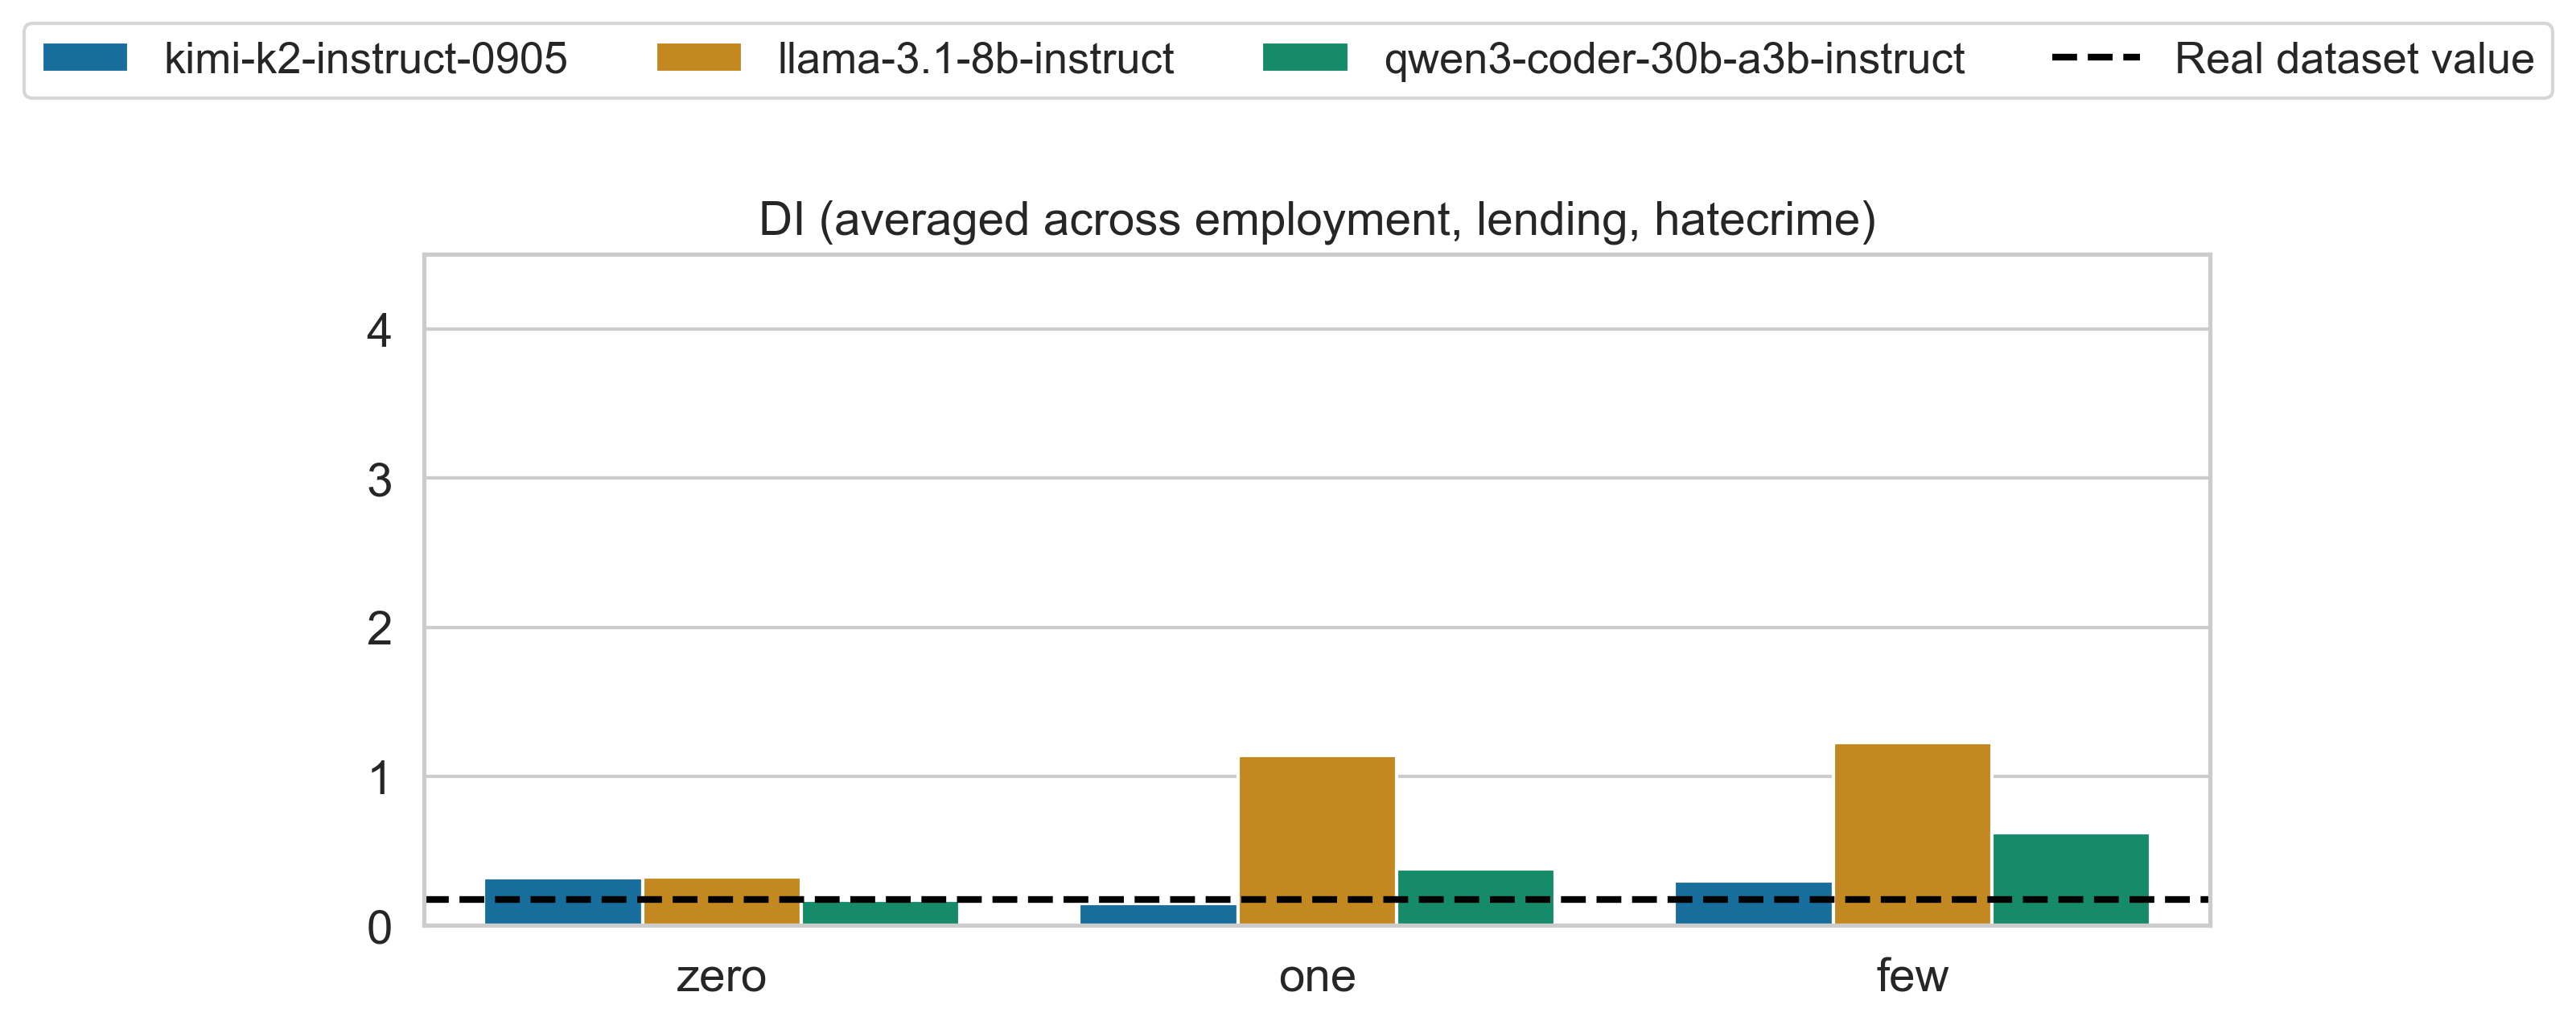

In [ ]:
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of {candidates} found in columns {list(df.columns)}")


def _plot_metric(ax, df, value_col, title, real_value, ylabel):
    df = df.copy()

    df["shot"] = pd.Categorical(df["shot"], categories=SHOT_ORDER, ordered=True)
    df["model"] = pd.Categorical(df["model"], categories=MODEL_ORDER, ordered=True)

    palette = model_color_map(MODEL_ORDER)

    sns.barplot(
        ax=ax,
        data=df,
        x="shot",
        y=value_col,
        hue="model",
        palette=palette,
        errorbar=None,
    )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=18)

    ax.tick_params(labelsize=14)

    ax.axhline(real_value, color="black", linestyle="--",
               linewidth=1.2, label="Real dataset value")
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()


def best_per_shot(df, value_col, real_value, metric_name):
    rows = []
    for shot in df["shot"].cat.categories if hasattr(df["shot"], "cat") else df["shot"].unique():
        sub = df[df["shot"] == shot]
        if sub.empty:
            continue
        sub = sub.copy()
        sub["abs_diff"] = (sub[value_col] - real_value).abs()
        best_row = sub.loc[sub["abs_diff"].idxmin()]
        rows.append({
            "Metric": metric_name,
            "Shot": shot,
            "Best model": best_row["model"],
            "Value": best_row[value_col],
            "Real dataset value": real_value,
            "Abs diff": best_row["abs_diff"],
        })
    return rows


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "analysis" / "bias_rq_02"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

emp_bp_df = pd.read_csv(RESULTS_DIR / "employment_e01_base_rate_parity.csv")
emp_di_df = pd.read_csv(RESULTS_DIR / "employment_e02_disparate_impact.csv")
emp_md_df = pd.read_csv(RESULTS_DIR / "employment_e03_mean_difference.csv")
emp_real   = pd.read_csv(RESULTS_DIR / "employment_real_metrics.csv")

emp_bp_col = pick_col(emp_bp_df, ["bp_avg"])
emp_di_col = pick_col(emp_di_df, ["di_avg"])
emp_md_col = pick_col(emp_md_df, ["md_avg"])

emp_bp_real = emp_real[pick_col(emp_real, ["bp_avg"])].iloc[0]
emp_di_real = emp_real[pick_col(emp_real, ["di_avg"])].iloc[0]
emp_md_real = emp_real[pick_col(emp_real, ["md_avg"])].iloc[0]

lend_bp_df = pd.read_csv(RESULTS_DIR / "lending_e01_base_rate_parity.csv")
lend_di_df = pd.read_csv(RESULTS_DIR / "lending_e02_disparate_impact.csv")
lend_br_df = pd.read_csv(RESULTS_DIR / "lending_e03_base_rate.csv")
lend_real  = pd.read_csv(RESULTS_DIR / "lending_real_metrics.csv")

lend_bp_col = pick_col(lend_bp_df, ["bp_overall"])
lend_di_col = pick_col(lend_di_df, ["di_overall"])
lend_br_col = pick_col(lend_br_df, ["br_overall"])

lend_bp_real = lend_real[pick_col(lend_real, ["overall_brp"])].iloc[0]
lend_di_real = lend_real[pick_col(lend_real, ["overall_di"])].iloc[0]
lend_br_real = lend_real[pick_col(lend_real, ["overall_br"])].iloc[0]

hc_bp_df = pd.read_csv(RESULTS_DIR / "hatecrime_e01_base_rate_parity.csv")
hc_di_df = pd.read_csv(RESULTS_DIR / "hatecrime_e02_disparate_impact.csv")
hc_br_df = pd.read_csv(RESULTS_DIR / "hatecrime_e03_base_rate.csv")
hc_real  = pd.read_csv(RESULTS_DIR / "hatecrime_real_metrics.csv")

hc_bp_col = pick_col(hc_bp_df, ["brp_overall"])
hc_di_col = pick_col(hc_di_df, ["di_overall"])
hc_br_col = pick_col(hc_br_df, ["br_overall"])

hc_bp_real = hc_real[pick_col(hc_real, ["overall_brp"])].iloc[0]
hc_di_real = hc_real[pick_col(hc_real, ["overall_di"])].iloc[0]
hc_br_real = hc_real[pick_col(hc_real, ["overall_br"])].iloc[0]


emp_bp_dom = emp_bp_df.groupby(["model", "shot"], as_index=False)[emp_bp_col].mean()
lend_bp_dom = lend_bp_df.groupby(["model", "shot"], as_index=False)[lend_bp_col].mean()
hc_bp_dom = hc_bp_df.groupby(["model", "shot"], as_index=False)[hc_bp_col].mean()

emp_bp_dom.rename(columns={emp_bp_col: "bp"}, inplace=True)
lend_bp_dom.rename(columns={lend_bp_col: "bp"}, inplace=True)
hc_bp_dom.rename(columns={hc_bp_col: "bp"}, inplace=True)


bp_all = pd.concat([emp_bp_dom, lend_bp_dom, hc_bp_dom], ignore_index=True)
bp_agg = bp_all.groupby(["model", "shot"], as_index=False)["bp"].mean()


bp_real_avg = (emp_bp_real + lend_bp_real + hc_bp_real) / 3.0

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
_plot_metric(
    ax=ax,
    df=bp_agg,
    value_col="bp",
    title="BRP (averaged across employment, lending, hatecrime)",
    real_value=bp_real_avg,
    ylabel="Base Rate Parity",
)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=4,
    frameon=True,
    fancybox=True,
    fontsize=14,
    title_fontsize=14,
)
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.savefig(FIGURES_DIR / "brp_averaged.png", dpi=300, bbox_inches="tight")
plt.show()



emp_di_dom = emp_di_df.groupby(["model", "shot"], as_index=False)[emp_di_col].mean()
lend_di_dom = lend_di_df.groupby(["model", "shot"], as_index=False)[lend_di_col].mean()
hc_di_dom = hc_di_df.groupby(["model", "shot"], as_index=False)[hc_di_col].mean()

emp_di_dom.rename(columns={emp_di_col: "di"}, inplace=True)
lend_di_dom.rename(columns={lend_di_col: "di"}, inplace=True)
hc_di_dom.rename(columns={hc_di_col: "di"}, inplace=True)

di_all = pd.concat([emp_di_dom, lend_di_dom, hc_di_dom], ignore_index=True)
di_agg = di_all.groupby(["model", "shot"], as_index=False)["di"].mean()

di_real_avg = (emp_di_real + lend_di_real + hc_di_real) / 3.0

di_agg_transformed = di_agg.copy()
di_agg_transformed["di"] = (di_agg["di"] - 1.0).abs()
di_real_avg_transformed = abs(di_real_avg - 1.0)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
_plot_metric(
    ax=ax,
    df=di_agg_transformed,
    value_col="di",
    title="DI (averaged across employment, lending, hatecrime)",
    real_value=di_real_avg_transformed,
    ylabel="",
)
ax.set_ylim(0, 4.5)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=4,
    frameon=True,
    fancybox=True,
    fontsize=13,
    title_fontsize=13,
)
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.savefig(FIGURES_DIR / "di_averaged.png", dpi=300, bbox_inches="tight")
plt.show()


summary_rows = []
summary_rows.extend(best_per_shot(bp_agg, "bp", bp_real_avg, "BRP"))
summary_rows.extend(best_per_shot(di_agg, "di", di_real_avg, "DI"))

summary_df = pd.DataFrame(summary_rows)



In [ ]:
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of {candidates} found in columns {list(df.columns)}")


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "analysis" / "bias_rq_02"

emp_bp_df = pd.read_csv(RESULTS_DIR / "employment_e01_base_rate_parity.csv")
emp_di_df = pd.read_csv(RESULTS_DIR / "employment_e02_disparate_impact.csv")
emp_md_df = pd.read_csv(RESULTS_DIR / "employment_e03_mean_difference.csv")
emp_real   = pd.read_csv(RESULTS_DIR / "employment_real_metrics.csv")

emp_bp_col = pick_col(emp_bp_df, ["bp_avg"])
emp_di_col = pick_col(emp_di_df, ["di_avg"])
emp_md_col = pick_col(emp_md_df, ["md_avg"])


lend_bp_df = pd.read_csv(RESULTS_DIR / "lending_e01_base_rate_parity.csv")
lend_di_df = pd.read_csv(RESULTS_DIR / "lending_e02_disparate_impact.csv")
lend_br_df = pd.read_csv(RESULTS_DIR / "lending_e03_base_rate.csv")
lend_real  = pd.read_csv(RESULTS_DIR / "lending_real_metrics.csv")

lend_bp_col = pick_col(lend_bp_df, ["bp_overall"])
lend_di_col = pick_col(lend_di_df, ["di_overall"])
lend_br_col = pick_col(lend_br_df, ["br_overall"])


hc_bp_df = pd.read_csv(RESULTS_DIR / "hatecrime_e01_base_rate_parity.csv")
hc_di_df = pd.read_csv(RESULTS_DIR / "hatecrime_e02_disparate_impact.csv")
hc_br_df = pd.read_csv(RESULTS_DIR / "hatecrime_e03_base_rate.csv")
hc_real  = pd.read_csv(RESULTS_DIR / "hatecrime_real_metrics.csv")

hc_bp_col = pick_col(hc_bp_df, ["brp_overall"])
hc_di_col = pick_col(hc_di_df, ["di_overall"])
hc_br_col = pick_col(hc_br_df, ["br_overall"])


lend_bp_df.loc[(lend_bp_df["model"] == "kimi-k2-instruct-0905") & (lend_bp_df["shot"] == "one"), lend_bp_col] = float("nan")
lend_di_df.loc[(lend_di_df["model"] == "kimi-k2-instruct-0905") & (lend_di_df["shot"] == "one"), lend_di_col] = float("nan")


emp_bp_real = float(emp_real[pick_col(emp_real, ["bp_avg"])].iloc[0])
emp_di_real = float(emp_real[pick_col(emp_real, ["di_avg"])].iloc[0])

lend_bp_real = float(lend_real[pick_col(lend_real, ["overall_brp"])].iloc[0])
lend_di_real = float(lend_real[pick_col(lend_real, ["overall_di"])].iloc[0])

hc_bp_real = float(hc_real[pick_col(hc_real, ["overall_brp"])].iloc[0])
hc_di_real = float(hc_real[pick_col(hc_real, ["overall_di"])].iloc[0])

def build_metric_table(metric_name, domain_specs, real_value_map):
    domain_order = [d[0] for d in domain_specs]

    parts = []
    for domain_name, df, col in domain_specs:

        tmp = (
            df.groupby(["model", "shot"], as_index=False)[col]
              .mean()
              .rename(columns={col: "metric"})
        )
        tmp["domain"] = domain_name
        parts.append(tmp)

    all_df = pd.concat(parts, ignore_index=True)


    all_df["model"] = pd.Categorical(all_df["model"], categories=MODEL_ORDER, ordered=True)
    all_df["domain"] = pd.Categorical(all_df["domain"], categories=domain_order, ordered=True)
    all_df["shot"] = pd.Categorical(all_df["shot"], categories=SHOT_ORDER, ordered=True)
    all_df = all_df.sort_values(["model", "domain", "shot"])

    dom_avg = (
        all_df[all_df["metric"].notna()]
        .groupby(["model", "domain"], as_index=False)["metric"]
        .mean()
        .rename(columns={"metric": "domain_avg"})
    )

    all_df = all_df.merge(dom_avg, on=["model", "domain"], how="left")
    

    all_df["real_value"] = all_df["domain"].map(real_value_map)
    all_df["real_value"] = pd.to_numeric(all_df["real_value"], errors="coerce")
    

    all_df["metric"] = pd.to_numeric(all_df["metric"], errors="coerce")
    
    if metric_name == "DI":

        all_df["metric_abs_diff_from_1"] = (all_df["metric"] - 1.0).abs()
        all_df["real_value_abs_diff_from_1"] = (all_df["real_value"] - 1.0).abs()
        

        all_df["abs_diff"] = all_df.apply(
            lambda row: abs(row["metric_abs_diff_from_1"] - row["real_value_abs_diff_from_1"])
            if pd.notna(row["metric"]) and pd.notna(row["real_value"])
            else float("nan"),
            axis=1
        )
        all_df["metric"] = all_df["metric_abs_diff_from_1"]
        all_df["real_value"] = all_df["real_value_abs_diff_from_1"]
        
        dom_avg = (
            all_df[all_df["metric"].notna()]
            .groupby(["model", "domain"], as_index=False)["metric"]
            .mean()
            .rename(columns={"metric": "domain_avg"})
        )
        all_df = all_df.drop(columns=["domain_avg"], errors="ignore")
        all_df = all_df.merge(dom_avg, on=["model", "domain"], how="left")
    else:
        all_df["metric_diff_from_1"] = all_df["metric"] - 1.0
        all_df["real_value_diff_from_1"] = all_df["real_value"] - 1.0
        
        all_df["abs_diff"] = all_df.apply(
            lambda row: abs(row["metric_diff_from_1"] - row["real_value_diff_from_1"]) 
            if pd.notna(row["metric"]) and pd.notna(row["real_value"]) 
            else float("nan"),
            axis=1
        )
    
    abs_diff_dom_avg = (
        all_df[all_df["abs_diff"].notna()]
        .groupby(["model", "domain"], as_index=False)["abs_diff"]
        .mean()
        .rename(columns={"abs_diff": "abs_diff_dom_avg"})
    )
    all_df = all_df.merge(abs_diff_dom_avg, on=["model", "domain"], how="left")


    model_avg = (
        dom_avg[dom_avg["domain_avg"].notna()]
        .groupby("model", as_index=False)["domain_avg"]
        .mean()
        .rename(columns={"domain_avg": "model_avg"})
    )
    model_avg_dict = dict(zip(model_avg["model"], model_avg["model_avg"]))
    

    abs_diff_model_avg = (
        abs_diff_dom_avg[abs_diff_dom_avg["abs_diff_dom_avg"].notna()]
        .groupby("model", as_index=False)["abs_diff_dom_avg"]
        .mean()
        .rename(columns={"abs_diff_dom_avg": "abs_diff_model_avg"})
    )
    abs_diff_model_avg_dict = dict(zip(abs_diff_model_avg["model"], abs_diff_model_avg["abs_diff_model_avg"]))


    records = []
    for model in MODEL_ORDER:
        sub_model = all_df[all_df["model"] == model]
        if sub_model.empty:
            continue

        first_row_for_model = True

        for domain in domain_order:
            sub_dom = sub_model[sub_model["domain"] == domain]
            if sub_dom.empty:
                continue


            domain_name = sub_dom["domain"].iloc[0]
            real_val_original = real_value_map.get(domain_name, float("nan"))
            
           
            if metric_name == "DI":
               
                real_val = sub_dom["real_value"].iloc[0] if len(sub_dom) > 0 and "real_value" in sub_dom.columns else float("nan")
            else:
               
                real_val = real_val_original
            
  
            if "abs_diff_dom_avg" in sub_dom.columns and len(sub_dom) > 0:
                abs_diff_dom_avg_val = sub_dom["abs_diff_dom_avg"].iloc[0]
                if pd.isna(abs_diff_dom_avg_val):
                    abs_diff_dom_avg_val = float("nan")
            else:
                abs_diff_dom_avg_val = float("nan")
            
            for i, (_, r) in enumerate(sub_dom.iterrows()):
               
                show_domain_avg = (r["shot"] == SHOT_ORDER[-1])
                
        
                metric_val = r["metric"]
                if pd.isna(metric_val):
                    metric_val = float("nan")
                else:
                    metric_val = metric_val
                
 
                if "abs_diff" in r.index:
                    abs_diff_val = r["abs_diff"]
                    if pd.isna(abs_diff_val):
                        abs_diff_val = float("nan")
                else:
                    abs_diff_val = float("nan")

                records.append({
                    "Model": model if first_row_for_model and i == 0 else "",
                    "Domain": r["domain"],
                    "Shot": r["shot"],
                    "Value": metric_val,
                    "Real dataset value": real_val if i == 0 else "",  
                    "Abs difference": abs_diff_val,
                    "Abs difference per domain": abs_diff_dom_avg_val if show_domain_avg and not pd.isna(abs_diff_dom_avg_val) else (float("nan") if show_domain_avg else ""),
                })

            first_row_for_model = False

        records.append({
            "Model": "",
            "Domain": "",
            "Shot": f"Avg. per Model",
            "Value": "",
            "Real dataset value": "",
            "Abs difference": "",
            "Abs difference per domain": "",
        })

    table_df = pd.DataFrame(records)

    print("\n" + "=" * 80)
    print(f"{metric_name} – table")
    print("=" * 80)
    print(table_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


    return table_df

brp_real_map = {
    "employment": emp_bp_real,
    "lending": lend_bp_real,
    "hatecrime": hc_bp_real,
}
brp_table = build_metric_table(
    "BRP",
    [
        ("employment", emp_bp_df, emp_bp_col),
        ("hatecrime",  hc_bp_df,  hc_bp_col),
        ("lending",    lend_bp_df, lend_bp_col),
    ],
    brp_real_map,
)


di_real_map = {
    "employment": emp_di_real,
    "lending": lend_di_real,
    "hatecrime": hc_di_real,
}
di_table = build_metric_table(
    "DI",
    [
        ("employment", emp_di_df, emp_di_col),
        ("hatecrime",  hc_di_df,  hc_di_col),
        ("lending",    lend_di_df, lend_di_col),
    ],
    di_real_map,
)



BRP – table
                       Model     Domain           Shot  Value Real value Abs difference Abs difference per domain
       kimi-k2-instruct-0905 employment           zero 0.3568     0.1255         0.2313                          
                             employment            one 0.6590                    0.5335                          
                             employment            few 0.7888                    0.6633                    0.4760
                              hatecrime           zero 0.2593     0.4513         0.1920                          
                              hatecrime            one 0.3651                    0.0862                          
                              hatecrime            few 0.1652                    0.2861                    0.1881
                                lending           zero 0.0133     0.3262         0.3129                          
                                lending            one    NaN              